In [1]:
%%capture
!pip install pmdarima
from pmdarima import auto_arima
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
def importar_dados(caminho):
    dados = pd.read_csv(caminho)
    dados['data_iniSE'] = pd.to_datetime(dados['data_iniSE'])
    dados = dados.set_index('data_iniSE')
    dados = dados.asfreq('W-SUN')
    dados = dados.rename(columns={'umidmed': 'umidade', 'tempmed': 'temperatura'})
    dados = dados.dropna()
    return dados

In [3]:
dados_d = importar_dados('./dados/dengue_tratado.csv')
dados_ch = importar_dados('./dados/chikungunya_tratado.csv')
dados_zk = importar_dados('./dados/zika_tratado.csv')

In [4]:
def dividir_treino_teste(dados, data_limite):
    treino = dados[dados.index <= data_limite]
    teste = dados[dados.index > data_limite]
    return treino, teste

treino_d, teste_d = dividir_treino_teste(dados_d,'2022-01-02')
treino_ch, teste_ch = dividir_treino_teste(dados_ch,'2023-01-01')
treino_zk, teste_zk = dividir_treino_teste(dados_zk,'2023-01-01')

In [5]:
def separar_exog(treino, teste):
    exog_treino = treino[['umidade', 'temperatura']]
    exog_teste = teste[['umidade', 'temperatura']]
    treino = treino.drop(columns=['umidade', 'temperatura'])
    teste = teste.drop(columns=['umidade', 'temperatura'])
    return treino, teste, exog_treino, exog_teste

In [6]:
treino_d, teste_d, exog_treino_d, exog_teste_d = separar_exog(treino_d, teste_d)
treino_ch, teste_ch, exog_treino_ch, exog_teste_ch = separar_exog(treino_ch, teste_ch)
treino_zk, teste_zk, exog_treino_zk, exog_teste_zk = separar_exog(treino_zk, teste_zk)

In [7]:
exog_treino_ch

,umidade,temperatura
data_iniSE,,
2010-01-03,82.989629,27.444322
2010-01-10,82.638528,27.503644
2010-01-17,80.623241,27.698323
2010-01-24,76.221839,28.148011
2010-01-31,74.697437,28.655242
...,...,...
2022-12-04,81.968072,25.363636
2022-12-11,76.687227,25.733836
2022-12-18,81.822285,26.556090


In [8]:
def melhores_parame(treino, exog):
    modelo = auto_arima(treino,
    X=exog,
    seasonal=True,
    m=52,
    trace=True,
    suppress_warnings=True,
    stepwise=True,
    error_action='ignore')

    print(modelo.order)
    print(modelo.seasonal_order)

In [ ]:
melhores_parame(treino_d, exog_treino_d)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=3734.912, Time=42.84 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=4821.787, Time=0.48 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=3749.533, Time=21.87 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=4335.093, Time=10.16 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=4822.936, Time=0.62 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=3733.137, Time=32.79 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=3734.444, Time=2.57 sec
 ARIMA(2,0,2)(0,0,2)[52] intercept   : AIC=3734.891, Time=221.36 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=3733.034, Time=39.48 sec
 ARIMA(2,0,2)(2,0,0)[52] intercept   : AIC=3734.895, Time=183.38 sec
 ARIMA(2,0,2)(2,0,1)[52] intercept   : AIC=3736.895, Time=172.70 sec
 ARIMA(1,0,2)(1,0,0)[52] intercept   : AIC=3740.828, Time=30.10 sec
 ARIMA(2,0,1)(1,0,0)[52] intercept   : AIC=3752.429, Time=40.73 sec
 ARIMA(3,0,2)(1,0,0)[52] intercept   : AIC=3746.974, Time=57.59 sec
 ARIM

In [ ]:
melhores_parame(treino_ch, exog_treino_ch)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=2971.326, Time=56.89 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=3675.728, Time=0.40 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=3049.185, Time=27.96 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=3365.299, Time=34.10 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=3674.648, Time=0.49 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=2969.422, Time=48.50 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=2967.328, Time=2.44 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=2969.304, Time=47.88 sec
 ARIMA(1,0,2)(0,0,0)[52] intercept   : AIC=2971.345, Time=1.40 sec
 ARIMA(2,0,1)(0,0,0)[52] intercept   : AIC=2996.201, Time=1.83 sec
 ARIMA(3,0,2)(0,0,0)[52] intercept   : AIC=2966.359, Time=1.94 sec
 ARIMA(3,0,2)(1,0,0)[52] intercept   : AIC=2968.325, Time=68.16 sec
 ARIMA(3,0,2)(0,0,1)[52] intercept   : AIC=2968.325, Time=50.86 sec
 ARIMA(3,0,2)(1,0,1)[52] intercept   : AIC=2970.340, Time=64.25 sec
 ARIMA(3,0,

In [ ]:
melhores_parame(treino_zk, exog_treino_zk)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=2922.421, Time=52.79 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=3948.272, Time=0.51 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=2940.947, Time=18.84 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=3370.667, Time=27.69 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=3947.105, Time=0.35 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=2920.421, Time=43.84 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=2918.530, Time=1.46 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=2920.421, Time=33.94 sec
 ARIMA(1,0,2)(0,0,0)[52] intercept   : AIC=2919.440, Time=0.95 sec
 ARIMA(2,0,1)(0,0,0)[52] intercept   : AIC=2924.211, Time=1.33 sec
 ARIMA(3,0,2)(0,0,0)[52] intercept   : AIC=2886.769, Time=2.04 sec
 ARIMA(3,0,2)(1,0,0)[52] intercept   : AIC=2888.187, Time=56.64 sec
 ARIMA(3,0,2)(0,0,1)[52] intercept   : AIC=2888.223, Time=50.58 sec
 ARIMA(3,0,2)(1,0,1)[52] intercept   : AIC=2890.293, Time=60.83 sec
 ARIMA(3,0,

In [ ]:
#Dengue: ARIMA(2,0,2)(1,0,0)[52]
#Chik: ARIMA(3,0,2)(0,0,0)[52]
#Zika: ARIMA(3,0,2)(0,0,0)[52]

In [9]:
def treinar(treino, ordem, ordem_sazonal, exog):
    modelo = SARIMAX(treino, exog=exog, order=ordem, seasonal_order=ordem_sazonal, freq='W-SUN')
    resultado = modelo.fit()
    return resultado

In [12]:
modelo_d = treinar(treino_d, (2,0,2), (1,0,0,52), exog=exog_treino_d)

In [10]:
modelo_ch = treinar(treino_ch, (3,0,2), (1,0,0,52), exog=exog_treino_ch)

In [13]:
esperado_zk = pd.date_range(treino_zk.index.min(), treino_zk.index.max(), freq='W-SUN')
treino_zk = treino_zk.reindex(esperado_zk, fill_value=0)
exog_treino_zk = exog_treino_zk.reindex(esperado_zk).interpolate()

modelo_zk = treinar(treino_zk, (3,0,2), (1,0,0,52), exog=exog_treino_zk)

In [ ]:
modelo_d.save("./modelos/sarimax_dengue.pkl")
modelo_zk.save("./modelos/sarimax_zika.pkl")
modelo_ch.save("./modelos/sarimax_chik.pkl")

In [13]:
def walking_forward(treino, teste, resultado, exog_teste, futuro=6):
    previsoes = []
    datas_previstas = []

    for i in range(0, len(teste) - futuro + 1, futuro):
        bloco_teste = teste.iloc[i:i+futuro]
        bloco_exog = exog_teste.iloc[i:i+futuro]

        pred = resultado.forecast(steps=futuro, exog=bloco_exog)
        previsoes.extend(pred)
        datas_previstas.extend(bloco_teste.index)

        resultado = resultado.append(bloco_teste, exog=bloco_exog, refit=False)

    previsoes = pd.Series(previsoes, index=datas_previstas)
    reais = teste.loc[datas_previstas]
    
    previsoes = pd.DataFrame(previsoes)
    reais = pd.DataFrame(reais)
    return previsoes, reais

In [15]:
def avaliar_normalizado(y_predito, y_test):
    y_predito = np.array(y_predito).ravel()
    y_test = np.array(y_test).ravel()

    mae = mean_absolute_error(y_test, y_predito)
    rmse = root_mean_squared_error(y_test, y_predito)
    r2 = r2_score(y_test, y_predito)

    des_padrao = np.std(y_test)
    nmae = mae / des_padrao
    nrmse = rmse / des_padrao


    print(f"MAE:  {nmae:.2f}")
    print(f"RMSE: {nrmse:.2f}")
    print(f"R²:   {r2:.4f}")

In [16]:
previsoes_d, reais_d = walking_forward(treino_d, teste_d, modelo_d, exog_teste=exog_teste_d)
avaliar_normalizado(previsoes_d, reais_d)

MAE:  0.22
RMSE: 0.54
R²:   0.7032


In [17]:
previsoes_ch, reais_ch = walking_forward(treino_ch, teste_ch, modelo_ch, exog_teste=exog_teste_ch)
avaliar_normalizado(previsoes_ch, reais_ch)

MAE:  0.33
RMSE: 0.84
R²:   0.2929


In [18]:
previsoes_zk, reais_zk = walking_forward(treino_zk, teste_zk, modelo_zk, exog_teste=exog_teste_zk)
avaliar_normalizado(previsoes_zk, reais_zk)

MAE:  0.49
RMSE: 0.85
R²:   0.2838


In [72]:
def salar_dataFrames(reais, previsoes, arbo, modelo, caminho):
    dados = pd.merge(reais, previsoes, on=reais.index)
    dados = dados.rename(columns={"key_0": "data"})
    dados.index = pd.to_datetime(dados["data"])
    dados = dados.drop("data", axis=1)
    dados = dados.rename(columns={"casos": "y"})
    dados = dados.rename(columns={0: "y_pred"})
    dados.to_csv(f"{caminho}/{modelo}_{arbo}.csv", index=True)

In [74]:
salar_dataFrames(reais_d, previsoes_d, "Dengue", "sarimax", "./resultados/sarimax")
salar_dataFrames(reais_ch, previsoes_ch, "Chikungunya", "sarimax", "./resultados/sarimax")
salar_dataFrames(reais_zk, previsoes_zk, "Zika", "sarimax", "./resultados/sarimax")

# Gráficos

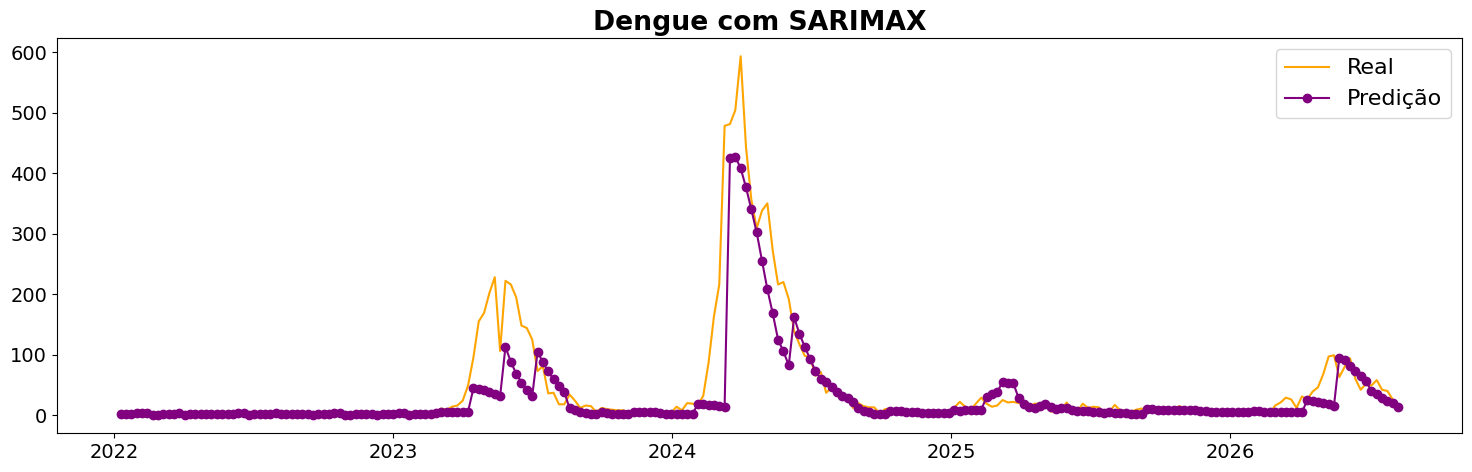

In [19]:
plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 16})

plt.title("Dengue com SARIMAX", fontweight='bold')
plt.plot(reais_d, color="orange", label="Real")
plt.plot(previsoes_d, color="purple", marker="o", label="Predição")
plt.legend()
plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('./graficos/Dengue_com_SARIMAX.png', bbox_inches='tight', dpi=300)
plt.show()

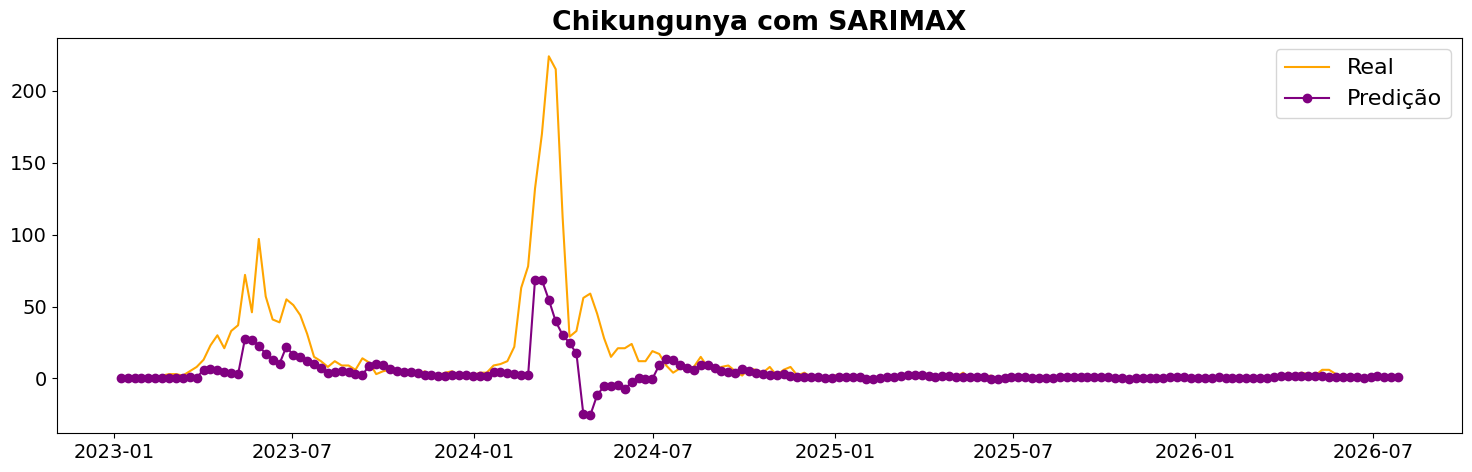

In [20]:
plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 16})

plt.title("Chikungunya com SARIMAX", fontweight='bold')
plt.plot(reais_ch, color="orange", label="Real")
plt.plot(previsoes_ch, color="purple", marker="o", label="Predição")
plt.legend()
plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('./graficos/Chikungunya_com_SARIMAX.png', bbox_inches='tight', dpi=300)
plt.show()

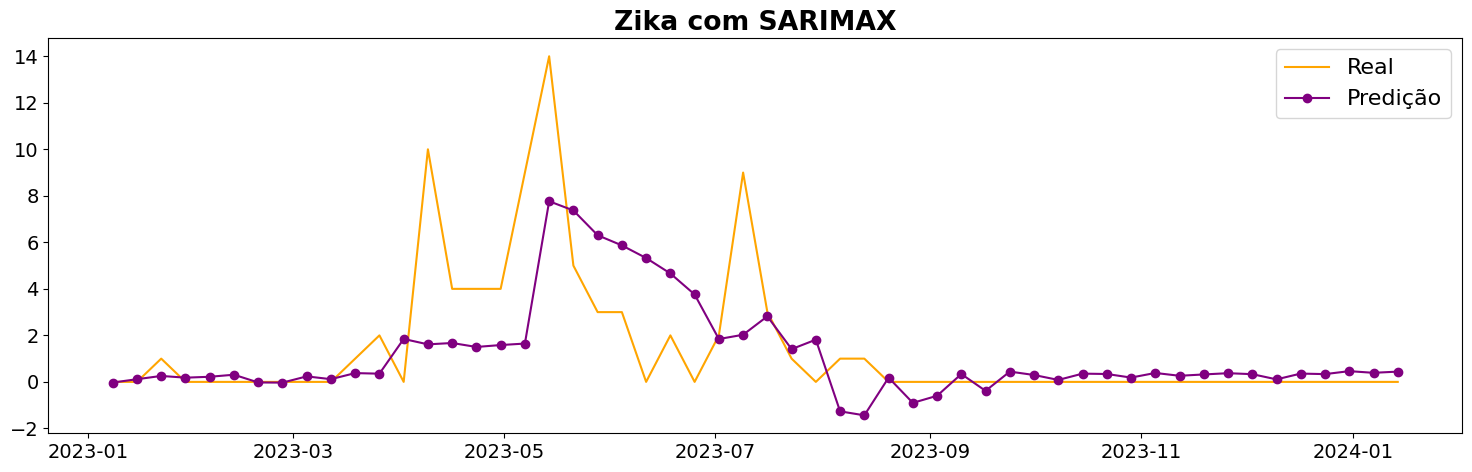

In [21]:
plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 16})

plt.title("Zika com SARIMAX", fontweight='bold')
plt.plot(reais_zk, color="orange", label="Real")
plt.plot(previsoes_zk, color="purple", marker="o", label="Predição")
plt.legend()
plt.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('./graficos/Zika_com_SARIMAX.png', bbox_inches='tight', dpi=300)
plt.show()